# Session 3: Model Explainability & Interpretability

In healthcare AI, a model's prediction is only as useful as a clinician's ability to understand and trust it. This session explores **SHAP (SHapley Additive exPlanations)**, the gold standard for model interpretability in clinical settings.

---

## What You'll Do Today

1. **Global Feature Importance** — Understand which features drive predictions across all patients
2. **Individual Patient Explanations** — Explain why a specific patient was flagged as high-risk
3. **Clinical Interpretation** — Translate SHAP values into actionable clinical insights
4. **Natural Language Explanations** — Generate human-readable risk explanations

---

## Why Explainability Matters in Healthcare

Healthcare AI operates under strict requirements that don't exist in other domains:

| Requirement | Why It Matters | How SHAP Helps |
|-------------|----------------|----------------|
| **Regulatory Compliance** | EU AI Act classifies medical AI as "high-risk" | Provides auditable explanations |
| **Clinical Trust** | Physicians won't use black-box predictions | Shows reasoning behind each score |
| **GDPR Article 22** | Patients have right to explanation | Enables meaningful disclosure |
| **Error Detection** | Catch models using spurious correlations | Reveals unexpected feature dependencies |
| **Liability** | Who's responsible when AI is wrong? | Creates documentation trail |

 **SwissCare Policy**: *"All risk scores must be accompanied by the top 3 contributing factors in plain language."*

---

## Import Libraries

We need SHAP for explainability alongside our standard ML toolkit.

**What is SHAP?**

SHAP (SHapley Additive exPlanations) provides a unified approach to feature importance based on **cooperative game theory**. The core idea comes from Nobel Prize-winning economist Lloyd Shapley: if multiple "players" (features) work together to produce an outcome (prediction), how do we fairly distribute credit among them?

**Why TreeExplainer?**

For tree-based models like XGBoost, SHAP offers `TreeExplainer` which provides:
- **Exact Shapley values** — No sampling or approximation needed
- **Computational efficiency** — Uses the tree structure to compute values in polynomial time
- **Consistency** — Same feature with same impact always gets same attribution

This makes SHAP the gold standard for explaining tree-based models in production healthcare systems.

## Setting Environment Up for Colab

Mount Google Drive and set the repository path so this notebook can access the EHR data and source code.

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


### Project Configuration

This notebook loads paths from a YAML config file instead of hard-coded paths.

**Setup (one-time):**
1. In Colab's left sidebar, click the **Key** icon (Secrets)
2. Add a secret named `PROJECT_CONFIG_PATH`
3. Set the value to your config file path (e.g., `/content/drive/MyDrive/Project/config.yaml`)
4. Toggle "Notebook access" ON

In [2]:
from google.colab import userdata
import yaml

try:
    config_path = userdata.get('PROJECT_CONFIG_PATH')
except:
    config_path = input("Enter path to your config.yaml: ")

with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

REPO_PATH = config['repo_path']
print(f"Repository path: {REPO_PATH}")

Repository path: /content/drive/MyDrive/MASAID/AI_Project_Group/repo


### Install Source Code as Package

`pip install` installs the local source code as a Python package so you can import directly from it (e.g., `from helpers import get_col`). Re-run this cell after making changes to the source code.

In [3]:
!pip install {REPO_PATH}/src/ shap xgboost -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [4]:
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Core libraries imported")

Core libraries imported


In [5]:
import shap
import xgboost as xgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, average_precision_score

def get_shap_values(raw):
    """Handle both list (multiclass) and array (binary) SHAP outputs."""
    if isinstance(raw, list):
        return raw[1] if len(raw) > 1 else raw[0]
    return raw

print("ML and SHAP libraries imported")

ML and SHAP libraries imported


In [6]:
DATA_DIR = os.path.join(REPO_PATH, 'data', 'week_2')
OUTPUT_DIR = os.path.join(REPO_PATH, 'data', 'week_3')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"DATA_DIR:   {DATA_DIR}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

DATA_DIR:   /content/drive/MyDrive/MASAID/AI_Project_Group/repo/data/week_2
OUTPUT_DIR: /content/drive/MyDrive/MASAID/AI_Project_Group/repo/data/week_3


---

## Load Data

We'll use the classifier training data from Week 2 containing time-series features engineered from patient timelines.

**Data Structure Reminder:**

| Column Type | Example | Purpose |
|-------------|---------|---------|
| **Patient ID** | `048f8fc9-cbd...` | Links instances to patients |
| **Date** | `date` | When the prediction was made |
| **Clinical features** | `current_hba1c_level`, `days_since_last_encounter` | Model inputs |
| **Label** | `will_have_high_risk_event_next_30d` | What we predict (0/1) |

Each row represents a patient at a specific point in time with features computed **only from historical data** (no data leakage). The label indicates whether a high-risk event occurred in the following 30 days — this is what our model predicts and what we need to explain.

In [7]:
# Load the pre-computed training data
classifier_data = pd.read_csv(
    os.path.join(DATA_DIR, 'classifier_training_data_22_features.csv'),
    low_memory=False
)

label_col = 'will_have_high_risk_event_next_30d'
patient_col = 'patient_id'

print(f"Loaded {len(classifier_data):,} instances")
print(f"Patients: {classifier_data['patient_id'].nunique():,}")

# Convert bmi_category from string to numeric (guard for already-numeric data)
if 'bmi_category' in classifier_data.columns and classifier_data['bmi_category'].dtype == 'object':
    bmi_mapping = {'underweight': 1, 'normal': 2, 'overweight': 3, 'obese': 4}
    classifier_data['bmi_category'] = classifier_data['bmi_category'].map(bmi_mapping)

# Drop rows with NaN labels
valid_mask = classifier_data[label_col].notna()
classifier_data = classifier_data[valid_mask].copy()
classifier_data[label_col] = classifier_data[label_col].astype(int)

Loaded 579,356 instances
Patients: 2,109


**Selecting Features for Explainability**

Next, we identify which columns are features (model inputs) vs metadata. We exclude columns containing patterns like `patient`, `id`, `date`, `label`, `risk`, etc. — these are identifiers or targets, not predictive features.

This step ensures we only explain features the model actually uses for prediction.

In [8]:
exclude_cols = ['patient_id', 'date']
exclude_patterns = ['label', 'risk', 'target', 'will_have', 'next', 'survival']
feature_cols = [col for col in classifier_data.columns
                if col not in exclude_cols
                and not any(pat in col.lower() for pat in exclude_patterns)]

print(f"Label: {label_col}")
print(f"Features: {len(feature_cols)}")

Label: will_have_high_risk_event_next_30d
Features: 22


---

## Patient-Level Train/Test Split

**Why Patient-Level Splitting?**

In our dataset, each patient has multiple time-series instances (one per day they were observed). If we did a naive random split, we might have:
- Patient A's Monday instance in training
- Patient A's Tuesday instance in testing

This is **data leakage** — the model learns patient-specific patterns during training and "recognizes" the same patient during testing, leading to falsely inflated performance metrics.

**The Solution: GroupShuffleSplit**

We use `GroupShuffleSplit` with `patient_id` as the grouping variable. This ensures:
- **All instances from a patient stay together** — Either entirely in train or entirely in test
- **No information leakage** — Test patients are truly "unseen" during training
- **Realistic evaluation** — Mimics deploying the model on new patients

This is the same splitting strategy we used during hyperparameter tuning in Session 2.

In [9]:
# NaN passthrough — this notebook uses only XGBoost, which handles NaN natively.
# SHAP's TreeExplainer also handles NaN correctly for tree-based models.
# Using fillna(0) would create clinically impossible values (e.g., eGFR=0, HbA1c=0)
# and distort SHAP explanations by attributing importance to the imputed zeros.
X = classifier_data[feature_cols]  # Keep NaN as-is
y = classifier_data[label_col]
groups = classifier_data[patient_col]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train: {len(X_train):,} instances")
print(f"Test:  {len(X_test):,} instances")
print(f"NaN passthrough: XGBoost and TreeExplainer handle missing values natively")


Train: 466,059 instances
Test:  113,297 instances
NaN passthrough: XGBoost and TreeExplainer handle missing values natively


---

## Load Pre-trained XGBoost Model

Instead of training from scratch, we load the tuned XGBoost model saved in **Session 2** (Advanced Pipeline). This model was optimized via random hyperparameter search and represents our best tree ensemble model.

**Why load instead of retrain?**

| Reason | Benefit |
|--------|---------|
| **Reproducibility** | Same model = same explanations every time |
| **Efficiency** | Avoids redundant training on ~580K instances |
| **Consistency** | Explanations match the model validated in Session 2 |
| **Best practices** | Production systems explain deployed models, not freshly trained ones |

In [10]:
# Load pre-trained XGBoost model from Session 2
model_path = os.path.join(OUTPUT_DIR, 'best_xgboost_model.pkl')

if not os.path.exists(model_path):
    raise FileNotFoundError(
        f"{model_path} not found. Run Session 2 first to train and save the model."
    )

try:
    with open(model_path, 'rb') as f:
        model = pickle.load(f)
except (EOFError, pickle.UnpicklingError) as e:
    raise RuntimeError(
        f"Model file is corrupted ({e}). Re-run Session 2's save cell to regenerate it."
    )

print(f"Loaded model from: {model_path}")
print(f"Model parameters: max_depth={model.max_depth}, "
      f"learning_rate={model.learning_rate}, "
      f"n_estimators={model.n_estimators}")

Loaded model from: /content/drive/MyDrive/MASAID/AI_Project_Group/repo/data/week_3/best_xgboost_model.pkl
Model parameters: max_depth=6, learning_rate=0.05, n_estimators=93


**Evaluate Loaded Model**

We verify the loaded model performs well on our test split. We use:
- **ROC-AUC**: How well the model ranks patients by risk (higher is better, 1.0 = perfect)
- **PR-AUC**: More appropriate for imbalanced data - measures precision-recall trade-off

Strong performance here confirms the model is worth explaining and that the train/test split produces consistent results.

In [11]:
y_prob = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print(f"Test ROC-AUC: {roc_auc:.4f}")
print(f"Test PR-AUC:  {pr_auc:.4f}")

Test ROC-AUC: 0.9544
Test PR-AUC:  0.8783


---

# SHAP Analysis

## What is SHAP?

SHAP values come from cooperative game theory. They answer: **"How much did each feature contribute to this prediction?"**

| Concept | Meaning | Example |
|---------|---------|----------|
| **Base value** | Average prediction across all patients | ~3% risk (reflects the low positive rate in our dataset) |
| **SHAP value** | Contribution of one feature | +8% from high HbA1c |
| **Final prediction** | Base + sum of all SHAP values | 15% + 8% + ... = 73% |

**Key properties:**
- SHAP values are **additive**: they sum to (prediction - base value)
- Positive SHAP = increases risk, Negative SHAP = decreases risk
- Magnitude = importance of that feature for this patient

## Create SHAP Explainer

For tree-based models like XGBoost, Random Forest, and LightGBM, we use `TreeExplainer`.

**Why TreeExplainer?**

| Explainer Type | Models | Computation | Accuracy |
|----------------|--------|-------------|----------|
| **TreeExplainer** | Tree ensembles (XGBoost, RF, LightGBM) | Fast (exact algorithm) | Exact Shapley values |
| **KernelExplainer** | Any model (model-agnostic) | Slow (sampling-based) | Approximate |
| **DeepExplainer** | Deep learning models | Moderate | Approximate |
| **LinearExplainer** | Linear models | Very fast | Exact |

**The Base Value (Expected Value)**

The explainer provides the **base value** — the average model output across the training data. This serves as the starting point for all individual explanations:

```
Individual Prediction = Base Value + sum(SHAP values for all features)
```

Note: TreeExplainer reports SHAP values in **log-odds space** (before the sigmoid). A base value of 0.0 in log-odds corresponds to a 50% probability — this is the model's internal reference point, not the dataset's positive rate. When features push the log-odds negative (as they do for most patients given the ~2.8% positive rate), the resulting probability drops well below 50%.

In [12]:
# Fix SHAP 0.49 / XGBoost >= 2.0: base_score stored as '[5E-1]'
# Monkey-patch builtins.float temporarily so TreeExplainer can parse '[5E-1]'.
# The restore line runs immediately after — if TreeExplainer itself crashes,
# restart the kernel (builtins.float will be reset).
import builtins
_builtin_float = builtins.float

def _safe_float(x):
    if isinstance(x, str) and x.startswith('[') and x.endswith(']'):
        return _builtin_float(x.strip('[]'))
    return _builtin_float(x)

builtins.float = _safe_float
explainer = shap.TreeExplainer(model)
builtins.float = _builtin_float  # always restore immediately

print("SHAP TreeExplainer created")
base_value = explainer.expected_value
if hasattr(base_value, '__len__'):
    base_value = base_value[1] if len(base_value) > 1 else base_value[0]
base_prob = 1 / (1 + np.exp(-float(base_value)))
print(f"Base value (log-odds): {float(base_value):.4f}")
print(f"Base value (probability): {base_prob:.4f}")


ERROR:tornado.application:Exception in callback functools.partial(<function Kernel._flush_control_queue.<locals>._flush at 0x7d81f4838ea0>)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tornado/ioloop.py", line 758, in _run_callback
    ret = callback()
          ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelbase.py", line 301, in _flush
    self.control_stream.flush()
  File "/usr/local/lib/python3.12/dist-packages/zmq/eventloop/zmqstream.py", line 469, in flush
    events = self.poller.poll(0)
             ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/zmq/sugar/poll.py", line 104, in poll
    elif isinstance(timeout, float):
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: isinstance() arg 2 must be a type, a tuple of types, or a union


SHAP TreeExplainer created
Base value (log-odds): 0.0000
Base value (probability): 0.5000


**Computing SHAP Values on a Sample**

We compute SHAP values on a **sample** of test data (500 instances) rather than the full test set for two reasons:

1. **Computational efficiency**: Even with TreeExplainer, computing 22 SHAP values for all ~113K test instances takes time
2. **Visualization clarity**: Summary plots become unreadable with too many points

**Production Pattern**: In a deployed system, you wouldn't pre-compute SHAP values for all patients. Instead, compute them **on-demand** when a clinician reviews a specific patient's risk score. This ensures explanations are always current.

**Output Shape**: The SHAP values matrix has shape `(n_samples, n_features)` — one SHAP value per feature per patient. Positive values increase risk; negative values decrease it.

In [13]:
n_samples = min(500, len(X_test))
X_test_sample = X_test.sample(n=n_samples, random_state=42)

print(f"Computing SHAP values for {n_samples} samples...")
shap_values_raw = explainer.shap_values(X_test_sample)
shap_values = get_shap_values(shap_values_raw)

print(f"SHAP values shape: {shap_values.shape}")

Computing SHAP values for 500 samples...
SHAP values shape: (500, 22)


---

## Global Feature Importance

Global importance answers: **"Which features matter most across all patients?"**

**How We Compute It: Mean Absolute SHAP**

For each feature, we calculate the **mean of the absolute SHAP values** across all samples:

```
Importance(feature) = mean(|SHAP values for feature|)
```

We use absolute values because:
- A feature with SHAP = +0.5 for some patients and -0.5 for others still has high importance
- We care about **impact magnitude**, not direction
- Positive and negative contributions shouldn't cancel out

**SHAP vs Built-in Feature Importance**

| Metric | What It Measures | Limitation |
|--------|------------------|------------|
| **Gini/Gain importance** | Total impurity reduction across splits | Biased toward high-cardinality features; doesn't show direction |
| **SHAP importance** | Actual impact on predictions | More computationally expensive |

SHAP importance is preferred because it measures **actual contribution to predictions**, not just usage frequency.

---

<details>
<summary><strong>Hint 1 — Mean |SHAP| computation</strong> (click to expand)</summary>

`mean_abs_shap = np.abs(shap_values).mean(axis=0)` — this gives one value per feature. We use absolute values because a feature with +0.5 for some patients and -0.5 for others still has high importance.
</details>

In [14]:
# TODO: Compute mean |SHAP| for each feature
#   1. Take absolute values of shap_values: np.abs(shap_values)
#   2. Compute the mean across all patients (axis=0)
#   3. Build a DataFrame with 'feature' and 'importance' columns
#   4. Sort by importance descending
#
#   HINT: mean_abs_shap = np.abs(shap_values).mean(axis=0)
mean_abs_shap = np.abs(shap_values).mean(axis=0)

feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': mean_abs_shap
}).sort_values('importance', ascending=False)

print("Global Feature Importance (Mean |SHAP|):")
print("=" * 50)
for i, row in feature_importance.head(10).iterrows():
    print(f"  {row['feature']:40} {row['importance']:.4f}")

Global Feature Importance (Mean |SHAP|):
  days_since_last_hba1c                    0.9862
  hba1c_trend_last_180d                    0.4460
  current_hba1c_level                      0.3774
  days_since_last_encounter                0.2710
  current_egfr                             0.2520
  bp_trend_last_180d                       0.2084
  current_systolic_bp                      0.1473
  active_medication_count                  0.1214
  days_since_emergency_visit               0.0809
  current_diastolic_bp                     0.0732


### SHAP Summary Plot (Beeswarm)

The beeswarm plot is the most information-dense SHAP visualization, showing both feature importance and effect direction in a single view.

**How to Read It:**

| Element | Meaning |
|---------|---------|
| **Y-axis** | Features ranked by importance (top = most important) |
| **X-axis** | SHAP value (left = decreases risk, right = increases risk) |
| **Each dot** | One patient's SHAP value for that feature |
| **Color** | Feature value (red = high, blue = low) |
| **Spread** | How consistently the feature affects predictions |

**Clinical Interpretation Example:**

If you see `current_hba1c_level` at the top with:
- Red dots (high HbA1c values) on the right → High HbA1c increases risk — Clinically correct!
- Blue dots (low HbA1c values) on the left → Low HbA1c decreases risk — Clinically correct!

This pattern validates the model learned the correct clinical relationship.

---

<details>
<summary><strong>Hint 1 — shap.summary_plot API</strong> (click to expand)</summary>

`shap.summary_plot(shap_values, X_test_sample, max_display=15, show=False)` — the default is a beeswarm plot. Pass `plot_type="bar"` for a bar chart instead.
</details>

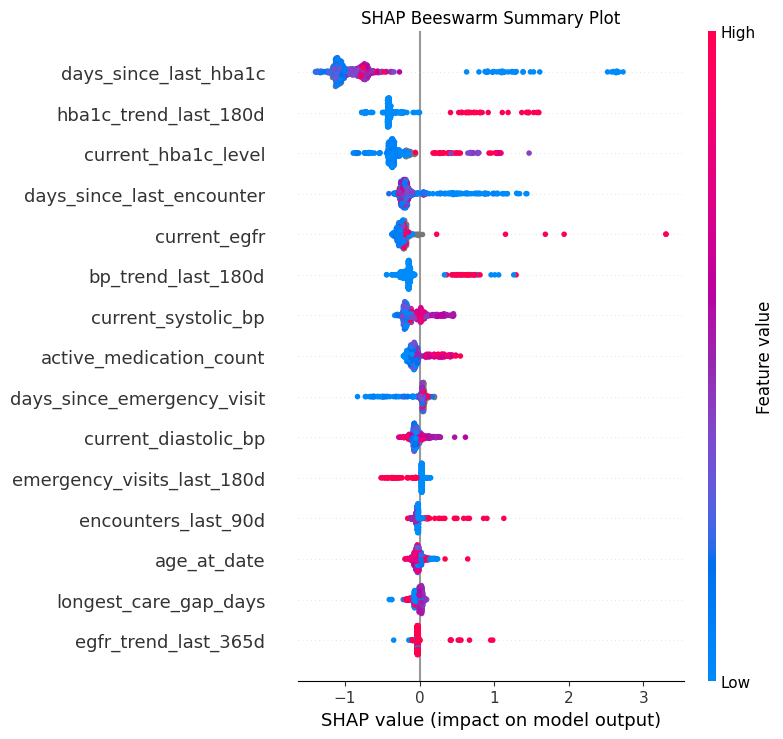

In [15]:
# TODO: Create a SHAP beeswarm summary plot
#   1. Use shap.summary_plot(shap_values, X_test_sample, ...)
#   2. Set max_display=15 and show=False
#   3. Add a title with plt.title()
#
#   HINT: shap.summary_plot(shap_values, X_test_sample, max_display=15, show=False)
plt.figure(figsize=(10, 8))
# Your code here
shap.summary_plot(shap_values, X_test_sample, max_display=15, show=False)
plt.title("SHAP Beeswarm Summary Plot")
plt.tight_layout()
plt.show()

### SHAP Bar Plot

The bar plot provides a **simplified view** of global feature importance, showing only the mean absolute SHAP value for each feature as horizontal bars.

**When to Use Bar Plot vs Beeswarm:**

| Plot Type | Shows | Best For |
|-----------|-------|----------|
| **Beeswarm** | Individual data points with color | Understanding *how* features affect predictions |
| **Bar** | Aggregated importance only | Executive summaries, presentations, quick comparisons |

**Clinical Insight**: The bar plot is what you'd include in a regulatory submission or board presentation — it clearly answers "what matters most" without requiring explanation of the color encoding or individual points.

For our diabetes risk model, we expect to see **HbA1c-related features** and **care gap features** at the top, as these are clinically validated risk factors.

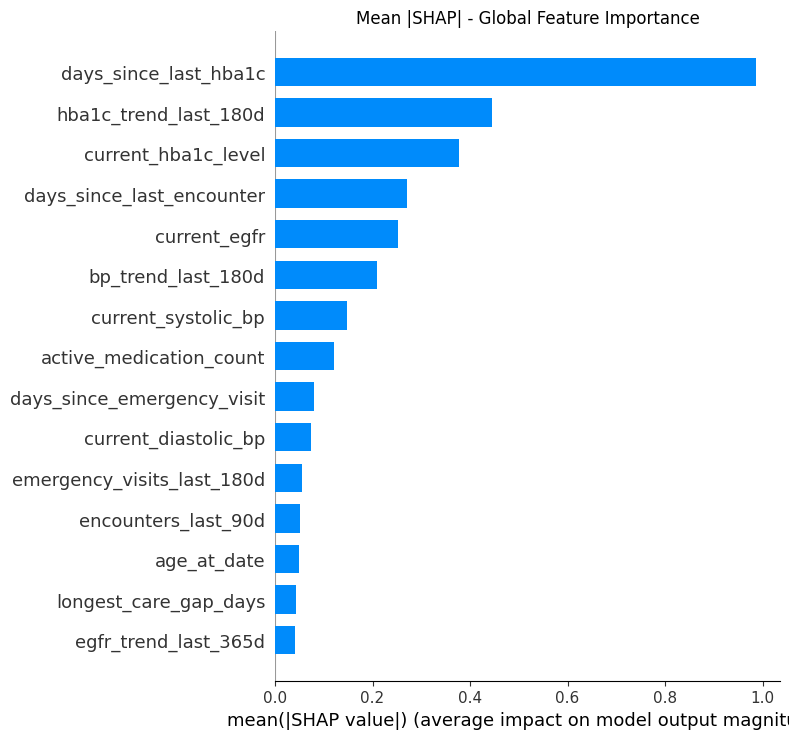

In [16]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", max_display=15, show=False)
plt.title("Mean |SHAP| - Global Feature Importance")
plt.tight_layout()
plt.show()

---

## Feature Dependence Plots

Dependence plots answer: **"How does a feature's value affect its SHAP contribution?"**

**Reading the Plot:**
- **X-axis**: The feature's actual value
- **Y-axis**: The feature's SHAP value (contribution to prediction)
- **Color**: A second feature that SHAP automatically selects based on interaction strength

**What to Look For:**

| Pattern | Meaning | Example |
|---------|---------|---------|
| **Upward slope** | Higher values → higher risk | HbA1c: more = worse |
| **Downward slope** | Higher values → lower risk | eGFR: more = better kidney function |
| **Threshold effect** | Risk jumps at specific value | HbA1c > 7.0 triggers concern |
| **Color separation** | Interaction between features | HbA1c effect differs by age |

**Clinical Validation**: If HbA1c shows a threshold around 7.0% (the ADA treatment target), the model has learned a clinically meaningful pattern. If the threshold is at an arbitrary value, we should investigate data quality or model issues.

---

<details>
<summary><strong>Hint 1 — Dependence plot API</strong> (click to expand)</summary>

```python
shap.dependence_plot(feature_name, shap_values, X_test_sample, ax=axes[i], show=False)
```

SHAP will auto-detect the best interaction feature for coloring.
</details>

In [17]:
top_features = feature_importance['feature'].head(4).tolist()

print("Generating dependence plots for top 4 features:")
for f in top_features:
    print(f"  - {f}")

Generating dependence plots for top 4 features:
  - days_since_last_hba1c
  - hba1c_trend_last_180d
  - current_hba1c_level
  - days_since_last_encounter


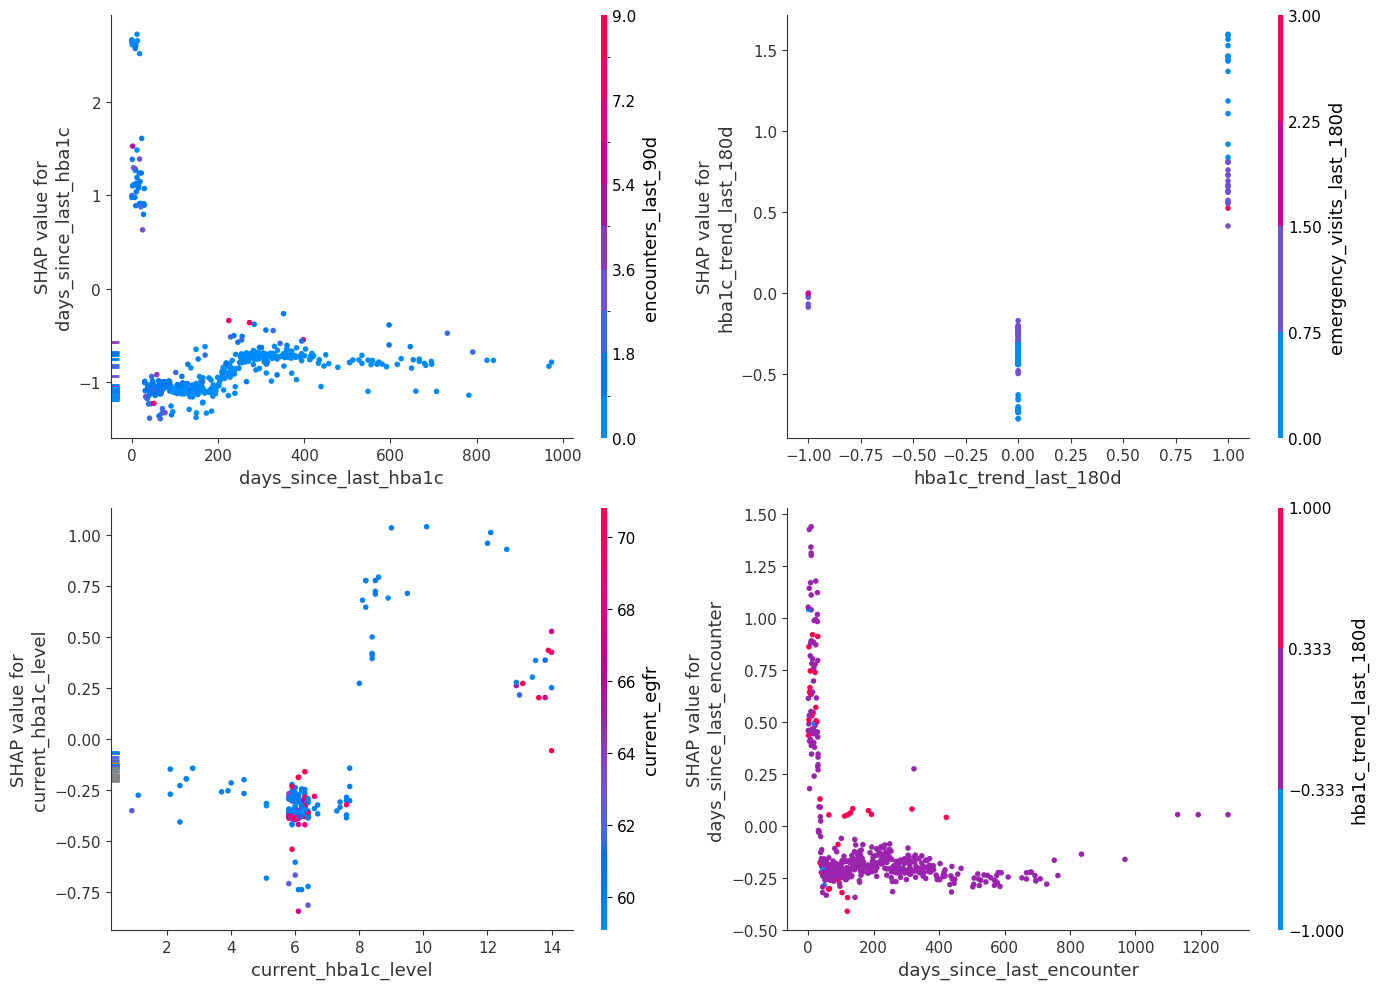

In [18]:
# TODO: Create dependence plots for the top 4 features
#   1. Create a 2x2 subplot grid: fig, axes = plt.subplots(2, 2, figsize=(14, 10))
#   2. Loop through top_features and call shap.dependence_plot() for each
#   3. Pass the correct ax= parameter for each subplot
#
#   HINT: shap.dependence_plot(feature_name, shap_values, X_test_sample, ax=axes[i], show=False)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    shap.dependence_plot(feature, shap_values, X_test_sample, ax=axes[i], show=False)

plt.tight_layout()
plt.show()

---

# Individual Patient Explanations

Global importance tells us what matters on average. But clinicians need to understand **specific patients**.

## Clinical Use Case

When a nurse sees a high-risk alert, they ask:
1. **Why is this patient flagged?** → SHAP explains the drivers
2. **What can we do about it?** → High SHAP features suggest interventions
3. **Is this alert trustworthy?** → Reasonable explanations build trust

## Identify High-Risk Patients

To demonstrate individual explanations, we first identify patients the model considers high-risk.

**Why 70% Threshold?**

In production, the threshold is a **business decision** that balances:
- **Lower threshold (e.g., 50%)**: Catch more true positives, but more false alarms
- **Higher threshold (e.g., 80%)**: Fewer false alarms, but miss some true positives

For demonstration, we use 70% — this represents the "definitely flag for review" tier in a tiered alert system. In practice, SwissCare might have:
- **> 80%**: Immediate phone call from care coordinator
- **60-80%**: Next-day outreach
- **40-60%**: Flag for next scheduled appointment

**What We're Identifying**: These are patients whose predicted probability of a high-risk event in the next 30 days exceeds our threshold. Each will receive an individual SHAP explanation.

In [35]:
high_risk_threshold = 0.7
high_risk_mask = y_prob > high_risk_threshold
high_risk_indices = np.where(high_risk_mask)[0]

print(f"Patients with risk > {high_risk_threshold:.0%}: {len(high_risk_indices):,}")
print(f"Percentage of test set: {len(high_risk_indices)/len(y_prob):.2%}")

Patients with risk > 70%: 3,215
Percentage of test set: 2.84%


**Selecting Patients for Demonstration**

We select a small sample of high-risk patients (3) to demonstrate the force plot explanation. In production, explanations would be generated on-demand for each patient a clinician reviews.

In [36]:
# Select sample of high-risk patients for explanation
# Ensure we pick instances from DIFFERENT patients for diverse examples
n_explain = min(3, len(high_risk_indices))
high_risk_df = pd.DataFrame({
    'idx': high_risk_indices,
    'patient_id': classifier_data.iloc[test_idx[high_risk_indices]][patient_col].values
})
# One instance per unique patient, then take first n_explain
sample_high_risk = high_risk_df.drop_duplicates('patient_id').head(n_explain)['idx'].values

print(f"\nSelected {len(sample_high_risk)} high-risk patients (from different patients) for detailed explanation")


Selected 3 high-risk patients (from different patients) for detailed explanation


## SHAP Force Plot

Force plots visualize individual predictions as a **"tug of war"** between features pushing the prediction up vs down.

**Reading the Force Plot:**

| Element | Meaning |
|---------|---------|
| **Base value** | Starting point (population average prediction) |
| **Red arrows** | Features pushing prediction **higher** (increasing risk) |
| **Blue arrows** | Features pushing prediction **lower** (decreasing risk) |
| **Arrow width** | Magnitude of contribution |
| **Final value** | Where the arrows end (model's prediction) |

**Clinical Analogy**: Think of the base value as "average patient risk." Red factors are like warning signs that make this patient worse than average. Blue factors are protective elements keeping the risk from being even higher.

**Why This Matters for Clinicians**: Instead of just seeing "78% risk," a clinician can see:
- "High HbA1c (+15%) is the main driver"
- "Care gap of 6 months (+10%) is concerning"
- "Active medication count (-5%) is somewhat protective"

This transforms an opaque score into actionable insights.

In [37]:
shap.initjs()

The `shap.initjs()` call above loads the JavaScript libraries needed for interactive force plots in Jupyter notebooks. This only needs to run once per notebook session.

**Compute SHAP Values for Selected Patient**

For the first high-risk patient, we compute their individual SHAP values and display their risk score alongside the actual outcome (did they have a high-risk event?). This shows whether the model correctly identified the risk.

---

<details>
<summary><strong>Hint 1 — Single patient SHAP</strong> (click to expand)</summary>

Use `X_test.iloc[[idx]]` (double brackets for DataFrame, not Series). Then `explainer.shap_values(patient_features)` returns the SHAP array. Use `get_shap_values()` to handle multiclass vs binary output.
</details>

In [40]:
# TODO: Compute SHAP values for the first high-risk patient
#   1. Get patient features: X_test.iloc[[patient_idx]]
#   2. Compute SHAP: explainer.shap_values(patient_features)
#   3. Extract positive-class values: get_shap_values(raw)
if len(sample_high_risk) > 0:
    patient_idx = sample_high_risk[0]
    patient_features = X_test.iloc[[patient_idx]]
    patient_shap_raw = explainer.shap_values(patient_features)
    patient_shap = get_shap_values(patient_shap_raw)

    print(f"Patient Index: {patient_idx}")
    print(f"Risk Score: {y_prob[patient_idx]:.1%}")
    print(f"Actual Label: {'HIGH-RISK EVENT' if y_test.iloc[patient_idx] else 'No event'}")

Patient Index: 295
Risk Score: 85.4%
Actual Label: HIGH-RISK EVENT


**Render Force Plot**

The force plot below visualizes this patient's prediction. Red arrows show features pushing risk higher; blue arrows show protective factors pulling it lower. The width of each arrow indicates the magnitude of that feature's contribution.

---

<details>
<summary><strong>Hint 1 — Force plot API</strong> (click to expand)</summary>

```python
shap.force_plot(float(exp_val), patient_shap[0], patient_features.iloc[0],
                matplotlib=True, show=False)
```

`exp_val` is the base value (expected value from the explainer). For binary classifiers, use `explainer.expected_value[1]` if it's a list.
</details>

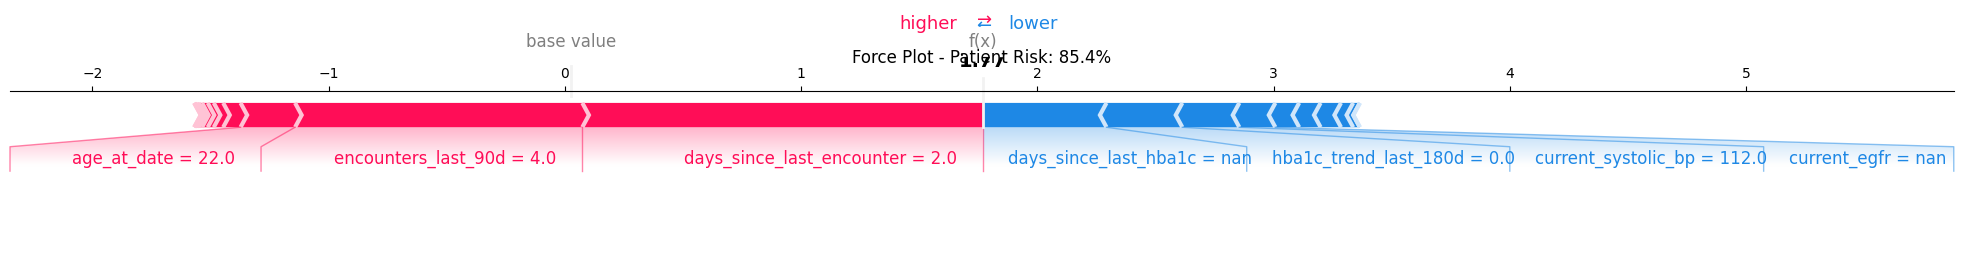

In [41]:
# TODO: Create a SHAP force plot for the selected patient
#   1. Get the base (expected) value from the explainer
#      - explainer.expected_value may be a scalar or list
#      - If it's a list, take index [1] for positive class
#   2. Call shap.force_plot() with:
#      - base_value (as float), SHAP values for this patient,
#        feature values, matplotlib=True, show=False
#   3. Add a title showing the patient's risk score
if len(sample_high_risk) > 0:
    # 1. Extract base value (handle scalar vs list)
    exp_val = (
        explainer.expected_value[1]
        if isinstance(explainer.expected_value, (list, np.ndarray))
        else explainer.expected_value
    )

    # 2. Create force plot
    shap.force_plot(
        float(exp_val),
        patient_shap[0],
        patient_features.iloc[0],
        matplotlib=True,
        show=False
    )

    # 3. Add title and display
    plt.title(
        f"Force Plot - Patient Risk: {y_prob[patient_idx]:.1%}",
        fontsize=12,
        pad=20
    )
    plt.tight_layout()
    plt.show()

---

## Natural Language Explanation Generator

Clinicians don't speak SHAP. We need to translate numerical explanations into actionable clinical language.

### The Explanation Framework

A good clinical explanation includes:
1. **Risk Level**: Clear categorization (HIGH/MODERATE/LOW)
2. **Top Risk Factors**: What's driving the prediction UP
3. **Protective Factors**: What's keeping the prediction from being even higher
4. **Clinical Context**: What these factors mean for care

---

<details>
<summary><strong>Hint 1 — contribution_pct calculation</strong> (click to expand)</summary>

`contribution_pct = |shap_i| / sum(|shap_all|) * 100` — this converts SHAP log-odds into a percentage budget. A feature with 25% contribution_pct accounts for 25% of the model's reasoning for this patient.
</details>

<details>
<summary><strong>Hint 2 — Splitting risk vs protective</strong> (click to expand)</summary>

Risk factors: `df[df['shap'] > 0].nlargest(top_n, 'shap')` — features pushing prediction UP.
Protective factors: `df[df['shap'] < 0].nsmallest(top_n, 'shap')` — features pulling prediction DOWN.
</details>

In [42]:
def generate_patient_explanation(features, shap_values, feature_names, risk_score, top_n=5):
    """
    Generate structured explanation from SHAP values.

    Returns dict with risk factors and protective factors.
    Each factor includes a 'contribution_pct' column showing what fraction
    of the total absolute SHAP budget that feature accounts for.

    Args:
        features: DataFrame row of feature values
        shap_values: SHAP values array for this patient
        feature_names: list of feature column names
        risk_score: predicted probability (0-1)
        top_n: number of factors to include in each category

    Returns:
        dict with keys: risk_score, risk_level, risk_factors, protective_factors
    """
    # Step 1: Compute total absolute SHAP
    total_abs_shap = np.sum(np.abs(shap_values))

    # Step 2: Build explanation DataFrame
    explanation_df = pd.DataFrame({
        'feature':          feature_names,
        'value':            np.array(features).flatten(),
        'shap':             shap_values.flatten(),
        'contribution_pct': np.abs(shap_values).flatten() / total_abs_shap * 100
    })

    # Step 3: Split into risk and protective factors
    risk_factors       = (explanation_df[explanation_df['shap'] > 0]
                            .nlargest(top_n, 'shap')
                            .reset_index(drop=True))

    protective_factors = (explanation_df[explanation_df['shap'] < 0]
                            .nsmallest(top_n, 'shap')
                            .reset_index(drop=True))

    # Step 4: Categorize risk level
    if   risk_score >= 0.8: risk_level = 'CRITICAL'
    elif risk_score >= 0.6: risk_level = 'HIGH'
    elif risk_score >= 0.4: risk_level = 'MODERATE'
    else:                   risk_level = 'LOW'

    return {
        'risk_score':        risk_score,
        'risk_level':        risk_level,
        'risk_factors':      risk_factors,
        'protective_factors': protective_factors
    }

print("Explanation generator defined")

Explanation generator defined


In [43]:
# Clinical interpretation mapping - all 22 features
CLINICAL_MEANINGS = {
    'age_at_date': 'Patient age - older patients have higher complication risk',
    'days_since_last_hba1c': 'Days since last HbA1c test - gaps indicate monitoring lapses',
    'days_since_last_encounter': 'Days since last clinical visit - longer gaps indicate care discontinuity',
    'days_since_medication_change': 'Days since medication adjustment - recent changes may indicate instability',
    'days_since_emergency_visit': 'Days since last ED visit - recent visits indicate acute episodes',
    'days_since_hospitalization': 'Days since last hospitalization - recent admits indicate severity',
    'encounters_last_90d': 'Recent encounter frequency - low values may indicate disengagement',
    'emergency_visits_last_180d': 'Recent ED visits - indicates acute decompensation episodes',
    'hospitalizations_last_365d': 'Recent hospitalizations - indicates severe disease burden',
    'medication_changes_last_90d': 'Recent medication changes - instability in treatment regimen',
    'current_hba1c_level': 'Most recent HbA1c value - higher values indicate poor glycemic control',
    'hba1c_trend_last_180d': 'HbA1c trend over 6 months - positive means worsening control',
    'current_systolic_bp': 'Systolic blood pressure - elevated values indicate hypertension risk',
    'current_diastolic_bp': 'Diastolic blood pressure - elevated values indicate hypertension risk',
    'bp_trend_last_180d': 'Blood pressure trend over 6 months - positive means worsening',
    'current_egfr': 'Estimated GFR - lower values indicate kidney damage (CKD progression)',
    'egfr_trend_last_365d': 'eGFR trend over 12 months - negative means declining kidney function',
    'bmi_category': 'BMI classification (1=underweight, 2=normal, 3=overweight, 4=obese)',
    'active_medication_count': 'Number of active medications - higher counts indicate treatment complexity',
    'diabetes_complication_count': 'Number of diabetes complications - indicates disease progression',
    'care_gaps_count': 'Number of care gaps - pattern of disengagement from care',
    'longest_care_gap_days': 'Maximum gap between encounters - indicates historical care discontinuity',
}

def get_clinical_meaning(feature_name):
    """Get clinical interpretation for a feature."""
    if feature_name in CLINICAL_MEANINGS:
        return CLINICAL_MEANINGS[feature_name]
    for key, meaning in CLINICAL_MEANINGS.items():
        if key in feature_name.lower():
            return meaning
    return "Clinical indicator contributing to risk assessment"

print(f"Defined clinical meanings for {len(CLINICAL_MEANINGS)} features")

Defined clinical meanings for 22 features


**Clinical Explanation Printer**

The `print_clinical_explanation()` function below formats the explanation output for clinical display, including risk level, contributing factors, and suggested interventions based on the `CLINICAL_MEANINGS` dictionary defined above.

---

<details>
<summary><strong>Hint 1 — Printing factors</strong> (click to expand)</summary>

```python
for _, row in explanation['risk_factors'].iterrows():
    meaning = get_clinical_meaning(row['feature'])
    val_str = "not measured" if pd.isna(row['value']) else f"{row['value']:.2f}"
    print(f"  - {row['feature']}")
    print(f"    Value: {val_str}  |  Contribution: {row['contribution_pct']:.1f}%")
    print(f"    -> {meaning}")
```
</details>

In [44]:
def print_clinical_explanation(explanation, patient_id="Unknown"):
    """
    Print formatted clinical explanation.
    Shows contribution_pct alongside raw SHAP so clinicians can see
    relative importance without understanding log-odds.

    Args:
        explanation: dict from generate_patient_explanation()
        patient_id: string identifier for display
    """
    print("\n" + "=" * 70)
    print("PATIENT RISK ASSESSMENT")
    print("=" * 70)
    print(f"Patient ID: {patient_id}")
    print(f"Risk Score: {explanation['risk_score']:.1%}")
    print(f"Risk Level: {explanation['risk_level']}")

    def _print_factors(factors_df, is_risk: bool):
        if factors_df is None or factors_df.empty:
            print("  (none identified)")
            return

        for _, row in factors_df.iterrows():
            feature_name  = row['feature']
            value         = row['value']
            shap_val      = row['shap']
            contribution  = row['contribution_pct']
            meaning       = get_clinical_meaning(feature_name)

            direction = "↑" if is_risk else "↓"
            print(f"  {direction} {feature_name}")
            print(f"     Value:        {value}")
            print(f"     Contribution: {contribution:.1f}%  (SHAP: {shap_val:+.4f})")
            print(f"     Meaning:      {meaning}")

    # Print risk-increasing factors
    print("\n" + "-" * 70)
    print("RISK-INCREASING FACTORS (Why risk is elevated):")
    print("-" * 70)
    _print_factors(explanation['risk_factors'], is_risk=True)

    # Print protective factors
    print("\n" + "-" * 70)
    print("PROTECTIVE FACTORS (What's keeping risk from being higher):")
    print("-" * 70)
    _print_factors(explanation['protective_factors'], is_risk=False)

    print("\n" + "=" * 70)

print("Clinical explanation printer defined")

Clinical explanation printer defined


## Generate Explanations for High-Risk Patients

Now we generate clinical explanations for our high-risk patients. Each explanation includes the risk level, the top factors pushing risk up (what's driving the alert), and protective factors (what's keeping the risk from being even higher). This mirrors how a care coordinator would want to understand a patient's situation.

In [45]:
print("Generating clinical explanations for high-risk patients...")

for i, idx in enumerate(sample_high_risk):
    patient_features = X_test.iloc[[idx]]
    patient_shap_raw = explainer.shap_values(patient_features)
    patient_shap = get_shap_values(patient_shap_raw)

    patient_risk = y_prob[idx]

    explanation = generate_patient_explanation(
        patient_features, patient_shap, feature_cols, patient_risk
    )

    patient_id = classifier_data.iloc[test_idx[idx]][patient_col]
    print_clinical_explanation(explanation, patient_id=patient_id[:12] + "...")

Generating clinical explanations for high-risk patients...

PATIENT RISK ASSESSMENT
Patient ID: 01c7d3fe-be8...
Risk Score: 85.4%
Risk Level: CRITICAL

----------------------------------------------------------------------
RISK-INCREASING FACTORS (Why risk is elevated):
----------------------------------------------------------------------
  ↑ days_since_last_encounter
     Value:        2.0
     Contribution: 34.4%  (SHAP: +1.6948)
     Meaning:      Days since last clinical visit - longer gaps indicate care discontinuity
  ↑ encounters_last_90d
     Value:        4.0
     Contribution: 24.6%  (SHAP: +1.2156)
     Meaning:      Recent encounter frequency - low values may indicate disengagement
  ↑ age_at_date
     Value:        22.0
     Contribution: 4.7%  (SHAP: +0.2308)
     Meaning:      Patient age - older patients have higher complication risk
  ↑ days_since_emergency_visit
     Value:        nan
     Contribution: 1.5%  (SHAP: +0.0735)
     Meaning:      Days since last ED visi

---

## Compare High-Risk vs Low-Risk Explanations

Understanding the contrast between high and low risk patients helps validate the model's reasoning. If high-risk patients have sensible explanations (care gaps, poor control, recent hospitalizations) while low-risk patients have the opposite pattern, we gain confidence the model learned meaningful clinical relationships rather than spurious correlations.

In [46]:
# Find low-risk patients from different patients
low_risk_threshold = 0.2
low_risk_all = np.where(y_prob < low_risk_threshold)[0]

low_risk_df = pd.DataFrame({
    'idx': low_risk_all,
    'patient_id': classifier_data.iloc[test_idx[low_risk_all]][patient_col].values
})
# One instance per unique patient, then take first 3
low_risk_indices = low_risk_df.drop_duplicates('patient_id').head(3)['idx'].values

print(f"Low-risk patients (< {low_risk_threshold:.0%}): {len(low_risk_indices)} (from different patients)")

Low-risk patients (< 20%): 3 (from different patients)


In [47]:
print("\n" + "#" * 70)
print("LOW-RISK PATIENT EXAMPLES (for comparison)")
print("#" * 70)

for idx in low_risk_indices:
    patient_features = X_test.iloc[[idx]]
    patient_shap_raw = explainer.shap_values(patient_features)
    patient_shap = get_shap_values(patient_shap_raw)

    patient_risk = y_prob[idx]

    explanation = generate_patient_explanation(
        patient_features, patient_shap, feature_cols, patient_risk, top_n=3
    )

    patient_id = classifier_data.iloc[test_idx[idx]][patient_col]
    print_clinical_explanation(explanation, patient_id=patient_id[:12] + "...")


######################################################################
LOW-RISK PATIENT EXAMPLES (for comparison)
######################################################################

PATIENT RISK ASSESSMENT
Patient ID: 4b2f0012-127...
Risk Score: 12.0%
Risk Level: LOW

----------------------------------------------------------------------
RISK-INCREASING FACTORS (Why risk is elevated):
----------------------------------------------------------------------
  ↑ days_since_last_encounter
     Value:        30.0
     Contribution: 11.2%  (SHAP: +0.3652)
     Meaning:      Days since last clinical visit - longer gaps indicate care discontinuity
  ↑ age_at_date
     Value:        32.0
     Contribution: 3.8%  (SHAP: +0.1242)
     Meaning:      Patient age - older patients have higher complication risk
  ↑ days_since_emergency_visit
     Value:        nan
     Contribution: 2.2%  (SHAP: +0.0725)
     Meaning:      Days since last ED visit - recent visits indicate acute episodes

---------

**Comparing the Results**

Notice the contrast between high-risk and low-risk patients: high-risk patients show elevated HbA1c, recent monitoring, and care gaps as dominant risk drivers, while low-risk patients have protective features keeping their scores below 20%. This pattern validates that the model learned clinically meaningful relationships rather than spurious correlations.

---

## Clinical Interpretation Summary

Let's create a reference table mapping our top features to clinical interpretations and potential interventions. This artifact is valuable for training clinical staff on how to interpret model outputs and translating alerts into actionable care plans. It also serves as documentation for regulatory compliance.

---

<details>
<summary><strong>Hint 1 — Keyword matching approach</strong> (click to expand)</summary>

Use `if 'hba1c' in feat.lower():` to match feature families. Map each to a (interpretation, intervention) pair. Example: `'hba1c'` -> `("Glycemic control marker", "Medication review, diabetes education referral")`.
</details>

In [50]:
top_10_features = feature_importance.head(10).copy()

interpretations = []
interventions = []

for feat in top_10_features['feature']:
    f = feat.lower()

    if 'days_since' in f or 'gap' in f:
        interpretation = "Care continuity indicator"
        intervention   = "Schedule follow-up appointment"

    elif 'hba1c' in f:
        interpretation = "Glycemic control marker"
        intervention   = "Medication review and dose adjustment"

    elif 'emergency' in f or 'hospital' in f:
        interpretation = "Acute healthcare utilization"
        intervention   = "Care coordination and transition planning"

    elif 'medication' in f:
        interpretation = "Treatment complexity indicator"
        intervention   = "Medication reconciliation and adherence support"

    elif 'complication' in f:
        interpretation = "Disease progression marker"
        intervention   = "Specialist referral and complication management"

    elif 'encounter' in f:
        interpretation = "Healthcare engagement pattern"
        intervention   = "Patient engagement and outreach program"

    elif 'egfr' in f:
        interpretation = "Kidney function indicator"
        intervention   = "Nephrology referral if eGFR declining"

    elif 'bp' in f or 'systolic' in f or 'diastolic' in f:
        interpretation = "Blood pressure control marker"
        intervention   = "Antihypertensive review and lifestyle counseling"

    elif 'age' in f:
        interpretation = "Age-related risk factor"
        intervention   = "Age-appropriate preventive care screening"

    else:
        interpretation = "Clinical indicator"
        intervention   = "Clinical review recommended"

    interpretations.append(interpretation)
    interventions.append(intervention)

top_10_features['clinical_interpretation'] = interpretations
top_10_features['suggested_intervention']   = interventions

In [51]:
print("CLINICAL INTERPRETATION REFERENCE")
print("=" * 100)
print(f"{'Feature':<35} {'Importance':<12} {'Interpretation':<30}")
print("-" * 100)

for _, row in top_10_features.iterrows():
    print(f"{row['feature'][:34]:<35} {row['importance']:<12.4f} {row['clinical_interpretation'][:29]:<30}")

CLINICAL INTERPRETATION REFERENCE
Feature                             Importance   Interpretation                
----------------------------------------------------------------------------------------------------
days_since_last_hba1c               0.9862       Care continuity indicator     
hba1c_trend_last_180d               0.4460       Glycemic control marker       
current_hba1c_level                 0.3774       Glycemic control marker       
days_since_last_encounter           0.2710       Care continuity indicator     
current_egfr                        0.2520       Kidney function indicator     
bp_trend_last_180d                  0.2084       Blood pressure control marker 
current_systolic_bp                 0.1473       Blood pressure control marker 
active_medication_count             0.1214       Treatment complexity indicato 
days_since_emergency_visit          0.0809       Care continuity indicator     
current_diastolic_bp                0.0732       Blood pressure c

---

## Save Explainability Artifacts

We save the feature importance tables with clinical interpretations for use in reports, documentation, and the agentic monitoring system.

**Why Save These Artifacts?**

| Artifact | Purpose | Who Uses It |
|----------|---------|-------------|
| **Feature importance CSV** | Reference for what drives predictions | Data scientists, model validators |
| **Clinical interpretation table** | Translate features to clinical meaning | Care coordinators, nurses |
| **Intervention suggestions** | Connect predictions to actions | Clinical leadership, protocol designers |

**Regulatory Compliance**: Under EU AI Act, high-risk AI systems (like medical prediction models) must maintain documentation of:
- Model behavior (feature importance satisfies this)
- Human oversight mechanisms (clinical interpretation enables this)
- Intervention pathways (suggested interventions document this)

These artifacts become part of the model's **audit trail** for regulatory review.

**Save Artifacts**

We save both the top-10 clinical interpretation table and the full feature importance to CSV files for downstream use in reports, regulatory documentation, and the agentic monitoring system.

In [52]:
# Save feature importance with clinical interpretations
top_10_features.to_csv(os.path.join(OUTPUT_DIR, 'shap_feature_importance_clinical.csv'), index=False)

print(f"Saved: {os.path.join(OUTPUT_DIR, 'shap_feature_importance_clinical.csv')}")

Saved: /content/drive/MyDrive/MASAID/AI_Project_Group/repo/data/week_3/shap_feature_importance_clinical.csv


In [53]:
# Save full feature importance
feature_importance.to_csv(os.path.join(OUTPUT_DIR, 'shap_feature_importance_full.csv'), index=False)

print(f"Saved: {os.path.join(OUTPUT_DIR, 'shap_feature_importance_full.csv')}")

Saved: /content/drive/MyDrive/MASAID/AI_Project_Group/repo/data/week_3/shap_feature_importance_full.csv


Both feature importance CSVs have been saved to `data/week_3/`. These provide a complete record of how the model weights each feature, serving as part of the audit trail for regulatory review.

---

## SHAP Limitations

SHAP is the best tool we have for tree-model explanations, but it is not perfect:

| Limitation | What It Means | Practical Impact |
|------------|---------------|------------------|
| **Feature independence assumption** | Shapley values assume features contribute independently | Correlated features (e.g., systolic & diastolic BP) split importance between them — neither gets full credit |
| **Correlation ≠ separated credit** | Two correlated features share SHAP budget | A feature can appear "unimportant" simply because a correlated partner absorbed most of the attribution |
| **Explanations ≠ causation** | SHAP shows what the *model* relies on, not what *causes* outcomes | High SHAP for `days_since_last_encounter` means the model uses it, not that skipping visits causes events |
| **Background data sensitivity** | TreeExplainer uses the training distribution as baseline | Explanations can shift if the patient population changes (e.g., different hospital, different demographics) |

**Bottom line:** SHAP explanations should inform clinical review, not replace it. Always pair SHAP outputs with domain expertise before acting on them.

---

## Summary

### What You Accomplished

1. **Loaded pre-trained XGBoost** from Session 2 and verified performance
2. **Created SHAP TreeExplainer** for fast, exact explanations
3. **Generated global feature importance** using mean absolute SHAP values
4. **Visualized feature effects** with summary plots and dependence plots
5. **Built individual patient explanations** with force plots
6. **Created natural language explanation generator** for clinical use
7. **Mapped all 22 features to clinical interpretations** and suggested interventions

### Key Insights

| Concept | Implementation | Clinical Value |
|---------|----------------|----------------|
| Global importance | Mean \|SHAP\| | Identifies key risk drivers across population |
| Individual explanations | Force plots | Shows why THIS patient is high-risk |
| Feature direction | SHAP sign | Reveals if feature increases or decreases risk |
| Clinical translation | Mapping table | Makes explanations actionable for clinicians |

### Next Steps

- **Session 4**: Assess model generalization and robustness
- **Homework**: Complete SHAP analysis and clinical explanation pipeline

### Professional Tip

In production, compute SHAP values **on-demand** for patients being reviewed, not in batch. This ensures explanations are current and reduces computational overhead. Store the explainer object, not pre-computed SHAP values.